Using Device = mps
Starting training on M2...
Epoch 20/200 | Loss: 0.018497
Epoch 40/200 | Loss: 0.009338
Epoch 60/200 | Loss: 0.008148
Epoch 80/200 | Loss: 0.007887
Epoch 100/200 | Loss: 0.007850
Epoch 120/200 | Loss: 0.006593
Epoch 140/200 | Loss: 0.006219
Epoch 160/200 | Loss: 0.005692
Epoch 180/200 | Loss: 0.005298
Epoch 200/200 | Loss: 0.005035


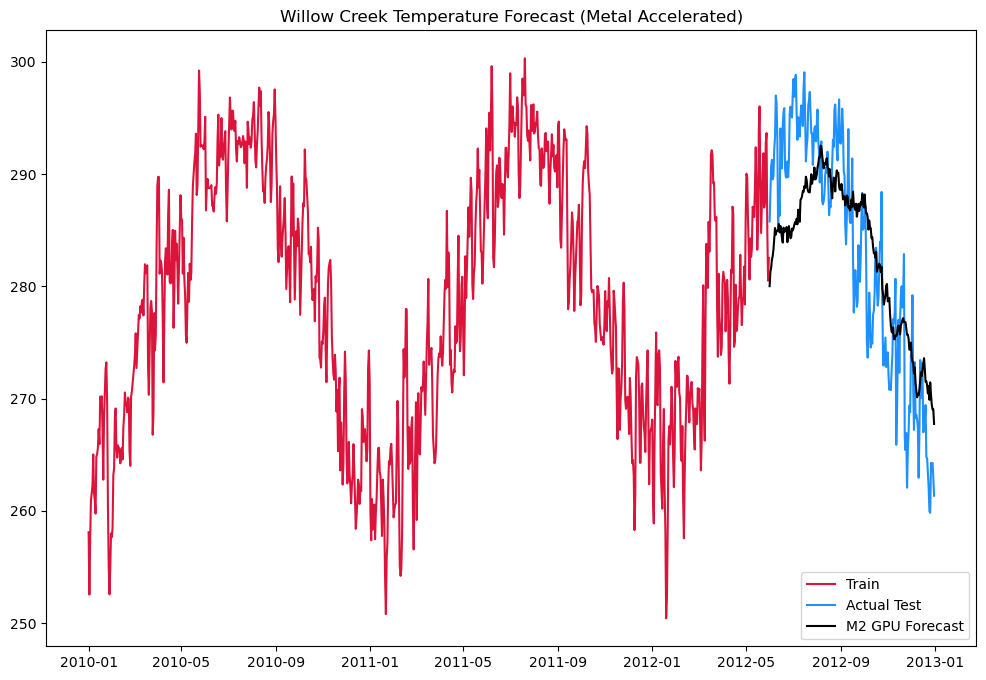

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from sklearn.preprocessing import MinMaxScaler
import warnings

#This is to not limit allocatable memory size.  Be carefull!
#PYTORCH_MPS_HIGH_WATERMARK_RATIO=0.0

warnings.filterwarnings("ignore")

FORCE_CPU = False

# 1. SETUP DEVICE FOR M2 MAC
# Check for Metal (MPS), then CUDA, then fallback to CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
    #print("Using M2 GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    #print("Using NVIDIA GPU")
else:
    device = torch.device("cpu")
    #print("Using CPU")
    
# 1b. FORCE M2 CPU FOR ACCURACY
if FORCE_CPU:
    device = torch.device("cpu")
    print("Targeting M2 CPU (AMX) for maximum precision...")

print(f'Using Device = {device}')

# 2. DATA LOADING & PROCESSING (Same as before)
ds = xr.open_mfdataset("./ML_Data/WCr*")['air_temperature']
ds_daily = ds.resample(time='1D').mean()
temp_daily = pd.DataFrame(
    index=pd.to_datetime(ds_daily.time.values),
    data=ds_daily.squeeze().values, 
    columns=['airT']
).dropna()

train_df = temp_daily['2010-01-01':'2012-05-31']
test_df = temp_daily['2012-06-01':'2012-12-31']

sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(temp_daily)

# Supervised Learning split
def split_sequence(sequence, n_input, n_output):
    X, Y = list(), list()
    for i in range(len(sequence)-n_input-n_output+1):
        end_ix = i + n_input
        out_end_ix = end_ix + n_output
        X.append(sequence[i:end_ix, 0])
        Y.append(sequence[end_ix:out_end_ix, 0])
    return np.array(X), np.array(Y)

n_input = 600      
n_output = len(test_df) 

X_train_np, y_train_np = split_sequence(training_set_scaled, n_input, n_output)

# Create Tensors and move to M2 GPU or CPU
X_train_t = torch.tensor(X_train_np, dtype=torch.float32).unsqueeze(-1).to(device)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32).to(device)

# Convert data and model to double precision.  This does not work on M2 GPU!!!
#X_train_t = X_train_t.to(torch.float64)
#Y_train_t = Y_train_t.to(torch.float64)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)

# 3. ENHANCED MODEL (No ReLU at output to prevent drops to 0, instead use nn.Linear)
class TimeSeriesLSTM(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=3, output_dim=214):
        super(TimeSeriesLSTM, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=0.2, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        # Using the last time step
        last_step = lstm_out[:, -1, :]
        return self.fc(last_step) # No ReLU here!

model = TimeSeriesLSTM(output_dim=n_output).to(device)

# Change hidden_dim from 64 (default) to 128 for better accuracy.  I don't have enough memory for this.
#model = TimeSeriesLSTM(input_dim=1, hidden_dim=128, num_layers=3, output_dim=n_output).to(device)
model = TimeSeriesLSTM(input_dim=1, hidden_dim=128, num_layers=2, output_dim=n_output).to(device)

# Force double precision for less rounding error.  This does not work on M2 GPU!!!
#model = model.to(torch.float64)

# 4. TRAINING
criterion = nn.MSELoss()
#optimizer = optim.Adam(model.parameters(), lr=0.0005) # Lower LR for stability

# If the M2 forecast looks "lazy" (not hitting the peaks), increase the learning rate
# slightly or add Weight Decay to force it to pay more attention to the errors:
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

epochs = 200
print("Starting training on M2...")
for epoch in range(epochs):
    model.train()
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        preds = model(batch_X)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.6f}")

# 5. PREDICTION (Device aware)
model.eval()
with torch.no_grad():
    traindataset_scaled = sc.transform(train_df)
    # Ensure input tensor is moved to M2 GPU
    traindataset_t = torch.tensor(traindataset_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    
    raw_prediction = model(traindataset_t)
    
    # Move back to CPU for numpy/matplotlib
    predicted_temp = sc.inverse_transform(raw_prediction.cpu().numpy().reshape(-1, 1))

# 6. VISUALIZATION
plt.figure(figsize=(12, 8))
plt.plot(train_df.index, train_df.airT, color='crimson', label='Train')
plt.plot(test_df.index, test_df.airT, color='dodgerblue', label='Actual Test')

if str(device) == 'mps':
    plt.plot(test_df.index, predicted_temp.flatten(), color='black', label='M2 GPU Forecast')
    plt.title("Willow Creek Temperature Forecast (Metal Accelerated)")
elif str(device) == 'cpu':
    plt.plot(test_df.index, predicted_temp.flatten(), color='black', label='M2 CPU Forecast')
    plt.title("Willow Creek Temperature Forecast (M2 AMX Accelerated)")
else:
    plt.plot(test_df.index, predicted_temp.flatten(), color='black', label=str(device))
    plt.title("Willow Creek Temperature Forecast")
plt.legend()


# Save the figure as a PNG file
figname = "forecast-gpu.png"
plt.savefig(figname)
plt.savefig(figname, dpi=300, bbox_inches='tight', transparent=True, format='png')

plt.show()